
# Representative 20-member subset from a 40-member E3SM–DART ensemble

This notebook:

1. discovers paired EAM and ELM files for EN01–EN40;
2. extracts compact atmospheric and land initial-state features;
3. searches reproducibly for a 20-member subset;
4. minimizes mismatch in ensemble mean, spread, and covariance;
5. compares the optimized subset against members 1–20;
6. writes the selected member IDs and diagnostics.

The same member IDs must be used for the paired atmosphere and land states.


In [10]:
from pathlib import Path
import importlib
import json
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HELPER_DIR = None
for candidate in (
    Path.cwd().resolve() / "util",
    Path.cwd().resolve() / "ensemble_ic" / "util",
):
    if (candidate / "dart_subset_selection.py").is_file():
        HELPER_DIR = candidate
        break
if HELPER_DIR is None:
    raise FileNotFoundError(
        "Could not find util/dart_subset_selection.py from the notebook working directory."
    )
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))

import dart_subset_selection as subset_helpers
subset_helpers = importlib.reload(subset_helpers)

from dart_subset_selection import (
    compute_member_features,
    configure_dask,
    discover_member_files,
    improve_by_swaps,
    inventory,
    make_subset_scorer,
    random_search_subsets,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

#machine = "perlmutter"
machine = "compy"
#case_name = "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy"
case_name = "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy"

if case_name == "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy":
    N_TOTAL_EXPECTED = 40
    SUBSET_SIZE = 20
    DATE_TAG = "2012-05-16-00000"
elif case_name == "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy":
    N_TOTAL_EXPECTED = 40
    SUBSET_SIZE = 20
    DATE_TAG = "2011-12-16-00000"
else:
    raise ValueError(f"Unknown case_name: {case_name}")

if machine == "compy":
    REST_DIR = Path(
        "/compyfs/zhan391/v3_dart_cda_scratch/",
        case_name,
        "archive",
        "rest",
        DATE_TAG,
    )
    OUTPUT_DIR = Path("/compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection") / DATE_TAG
elif machine == "perlmutter":
    REST_DIR = Path(
        "/global/cfs/cdirs/m4849/zhan391/e3sm_dart/",
        case_name,
        "archive",
        "rest",
        DATE_TAG,
    )
    OUTPUT_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/e3sm_dart_analysis/ensemble_ic/dart_subset_selection") / DATE_TAG

N_TRIALS = 100_000
RANDOM_SEED = 42
MAX_SAMPLE_POINTS = 50_000
MIN_UNIQUE_FEATURE_VALUES = 10
QUANTILES = (0.10, 0.25, 0.50, 0.75, 0.90)

USE_DASK = True
USE_DASK_DISTRIBUTED = False
DASK_N_WORKERS = min(8, os.cpu_count() or 1)
DASK_THREADS_PER_WORKER = 1
DASK_MEMORY_LIMIT = "4GB"
FEATURE_TASK_RETRIES = 1
RANDOM_SEARCH_BATCH_SIZE = 2_000

EAM_VARIABLE_CANDIDATES = ["T", "U", "V", "Q", "PS", "PHIS"]
ELM_VARIABLE_CANDIDATES = [
    "H2OSOI_LIQ", "H2OSOI_ICE", "T_SOISNO",
    "H2OSFC", "SNOWDP", "FSNO", "T_GRND",
]

WEIGHT_MEAN = 1.0
WEIGHT_STD = 1.0
WEIGHT_COV = 0.0

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dask_client = configure_dask(
    enabled=USE_DASK,
    use_distributed=USE_DASK_DISTRIBUTED,
    n_workers=DASK_N_WORKERS,
    threads_per_worker=DASK_THREADS_PER_WORKER,
    memory_limit=DASK_MEMORY_LIMIT,
)

print("REST_DIR:", REST_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("Dask enabled:", USE_DASK)


REST_DIR: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/rest/2011-12-16-00000
OUTPUT_DIR: /compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection/2011-12-16-00000
Dask enabled: True


## 1. Discover paired EAM and ELM files

In [11]:
if not REST_DIR.is_dir():
    raise FileNotFoundError(
        f"{REST_DIR} is unavailable. Run this notebook on Compy or edit REST_DIR."
    )

member_files = discover_member_files(REST_DIR, DATE_TAG)

display(member_files.head())
print("Paired members:", len(member_files))

if len(member_files) != N_TOTAL_EXPECTED:
    raise ValueError(
        f"Expected {N_TOTAL_EXPECTED} paired members, found {len(member_files)}."
    )


,member,eam_file,elm_file
0,1,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...
1,2,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...
2,3,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...
3,4,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...
4,5,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...,/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_...


Paired members: 40



## 2. Inspect candidate variables

Missing variables are skipped automatically. Modify the lists in the configuration cell after reviewing this inventory.


In [12]:
eam_inventory = inventory(member_files.loc[0, "eam_file"], EAM_VARIABLE_CANDIDATES)
elm_inventory = inventory(member_files.loc[0, "elm_file"], ELM_VARIABLE_CANDIDATES)

print("EAM variables found")
display(eam_inventory)
print("ELM variables found")
display(elm_inventory)

if eam_inventory.empty or elm_inventory.empty:
    raise ValueError("No usable EAM or ELM candidate variables were found.")


EAM variables found


,variable,dims,shape,dtype,units,long_name
0,T,"('time', 'lev', 'ncol_d')","(1, 80, 48602)",float64,K,Temperature
1,U,"('time', 'lev', 'ncol_d')","(1, 80, 48602)",float64,m/s,Zonal wind
2,V,"('time', 'lev', 'ncol_d')","(1, 80, 48602)",float64,m/s,Meridional wind
3,Q,"('time', 'lev', 'ncol_d')","(1, 80, 48602)",float64,kg/kg,Specific humidity
4,PS,"('time', 'ncol_d')","(1, 48602)",float64,Pa,Surface pressure


ELM variables found


,variable,dims,shape,dtype,units,long_name
0,H2OSOI_LIQ,"('column', 'levtot')","(1151701, 20)",float64,kg/m2,liquid water
1,H2OSOI_ICE,"('column', 'levtot')","(1151701, 20)",float64,kg/m2,ice lens
2,T_SOISNO,"('column', 'levtot')","(1151701, 20)",float64,K,soil-snow temperature
3,H2OSFC,"('column',)","(1151701,)",float64,kg/m2,surface water
4,T_GRND,"('column',)","(1151701,)",float64,K,ground temperature



## 3. Extract member-level features

Each field is summarized by its sampled mean, standard deviation, and five quantiles. A deterministic multidimensional stride keeps I/O manageable and samples the same locations for every member.


In [13]:
eam_variables = eam_inventory["variable"].tolist()
elm_variables = elm_inventory["variable"].tolist()

features_raw = compute_member_features(
    member_files,
    eam_variables=eam_variables,
    elm_variables=elm_variables,
    max_points=MAX_SAMPLE_POINTS,
    quantiles=QUANTILES,
    use_dask=USE_DASK,
    task_retries=FEATURE_TASK_RETRIES,
    min_unique=MIN_UNIQUE_FEATURE_VALUES,
)

feature_summary = pd.DataFrame({
    "raw_mean": features_raw.mean(),
    "raw_std": features_raw.std(ddof=1),
    "raw_min": features_raw.min(),
    "raw_max": features_raw.max(),
    "n_unique": features_raw.nunique(),
})

print("Feature matrix shape:", features_raw.shape)
print("Minimum unique values retained:", MIN_UNIQUE_FEATURE_VALUES)
display(features_raw.head())
print("Feature uniqueness and spread summary")
display(feature_summary.sort_values(["n_unique", "raw_std"]))

features_raw.to_csv(OUTPUT_DIR / "member_features_raw.csv")
feature_summary.to_csv(OUTPUT_DIR / "member_feature_summary.csv")


[                                        ] | 0% Completed | 359.38 us

[########################################] | 100% Completed | 54m 27s
Feature matrix shape: (40, 47)
Minimum unique values retained: 10


,EAM:T:mean,EAM:T:std,EAM:T:q10,EAM:T:q25,EAM:T:q50,EAM:T:q75,EAM:T:q90,EAM:U:mean,EAM:U:std,EAM:U:q10,...,ELM:H2OSOI_LIQ:q90,ELM:H2OSOI_ICE:mean,ELM:H2OSOI_ICE:std,ELM:T_SOISNO:mean,ELM:T_SOISNO:std,ELM:T_SOISNO:q10,ELM:H2OSFC:mean,ELM:H2OSFC:std,ELM:T_GRND:mean,ELM:T_GRND:std
member,,,,,,,,,,,,,,,,,,,,,
1,243.310874,30.872717,205.212476,215.840656,240.304229,270.529213,287.366645,5.806103,21.948424,-15.276135,...,82.880386,71.785748,762.438332,270.747143,48.205853,266.835175,49.772230,5079.434602,282.836305,11.729151
2,243.433406,30.782500,205.495977,216.032755,240.474278,270.589383,287.401528,5.994994,22.069004,-15.327236,...,82.723022,71.784604,762.436085,270.792901,48.059992,266.932054,49.773137,5079.434302,282.826200,11.752848
3,243.485236,30.758464,205.527405,216.160988,240.425983,270.581484,287.370464,5.867980,21.962763,-15.359966,...,82.880380,71.785815,762.438133,270.801865,48.031964,266.780834,49.771521,5079.431778,282.815244,11.765643
4,243.465557,30.773101,205.549760,216.048466,240.488464,270.582715,287.409151,5.831802,21.968130,-15.176438,...,82.723022,71.784763,762.436135,270.813573,48.032271,266.937787,49.771277,5079.432515,282.827641,11.757773
5,243.380194,30.839731,205.376075,215.939482,240.484155,270.539892,287.453511,5.858321,21.945743,-15.138018,...,82.723021,71.785279,762.434654,270.767855,48.148714,266.774718,49.772660,5079.433426,282.837827,11.726768


Feature uniqueness and spread summary


,raw_mean,raw_std,raw_min,raw_max,n_unique
ELM:H2OSOI_LIQ:q90,82.825203,1.082192e-01,82.723019,83.090761,38
EAM:Q:q25,0.000003,4.604191e-09,0.000003,0.000003,40
EAM:Q:q10,0.000003,1.321635e-08,0.000003,0.000003,40
EAM:Q:q50,0.000005,1.025325e-07,0.000005,0.000005,40
EAM:Q:mean,0.001930,4.464335e-06,0.001922,0.001938,40
EAM:Q:std,0.003875,7.894738e-06,0.003860,0.003893,40
EAM:Q:q75,0.001497,1.526673e-05,0.001464,0.001532,40
EAM:Q:q90,0.008205,3.926463e-05,0.008109,0.008290,40
ELM:H2OSOI_ICE:mean,71.785402,7.627581e-04,71.784064,71.787609,40
ELM:H2OSFC:mean,49.771752,7.838392e-04,49.770250,49.773380,40


## 4. Standardize features and define the objective

In [14]:
features_z = (
    (features_raw - features_raw.mean(axis=0))
    / features_raw.std(axis=0, ddof=1)
)
features_z.to_csv(OUTPUT_DIR / "member_features_standardized.csv")

Z = features_z.to_numpy(dtype=np.float64)
member_ids = features_z.index.to_numpy(dtype=int)

print("Feature matrix shape:", features_raw.shape)
print(
    "Number of unique member-feature rows:",
    np.unique(np.round(Z, 10), axis=0).shape[0],
)
print("Standardized feature matrix")
display(features_z)

subset_score, full_diagnostics = make_subset_scorer(
    Z,
    weight_mean=WEIGHT_MEAN,
    weight_std=WEIGHT_STD,
    weight_cov=WEIGHT_COV,
)
full_mean = full_diagnostics["full_mean"]
full_std = full_diagnostics["full_std"]

first20_indices = np.arange(SUBSET_SIZE)
first20_score, first20_parts = subset_score(first20_indices)
print("Members 1-20:", json.dumps(first20_parts, indent=2))


Feature matrix shape: (40, 47)
Number of unique member-feature rows: 40
Standardized feature matrix


,EAM:T:mean,EAM:T:std,EAM:T:q10,EAM:T:q25,EAM:T:q50,EAM:T:q75,EAM:T:q90,EAM:U:mean,EAM:U:std,EAM:U:q10,...,ELM:H2OSOI_LIQ:q90,ELM:H2OSOI_ICE:mean,ELM:H2OSOI_ICE:std,ELM:T_SOISNO:mean,ELM:T_SOISNO:std,ELM:T_SOISNO:q10,ELM:H2OSFC:mean,ELM:H2OSFC:std,ELM:T_GRND:mean,ELM:T_GRND:std
member,,,,,,,,,,,,,,,,,,,,,
1,-0.915176,0.840195,-1.299781,-0.936126,-1.193381,-0.763544,-0.806388,-0.863713,0.216693,-0.550113,...,0.509913,0.452867,2.251813,-1.183632,1.058633,-0.105339,0.609767,2.182120,-0.096496,-0.450733
2,0.694518,-0.920185,0.770328,0.840420,0.669378,0.408185,0.256790,1.868714,1.836713,-0.829970,...,-0.944205,-1.047236,0.289488,0.889808,-1.246297,1.430288,1.767208,1.851095,-0.902840,0.512498
3,1.375407,-1.389207,0.999815,2.026319,0.140336,0.254359,-0.689993,0.031381,0.409341,-1.009221,...,0.509863,0.541188,2.078198,1.295982,-1.689208,-0.966716,-0.293898,-0.929093,-1.777198,1.032561
4,1.116883,-1.103603,1.163051,0.985711,0.824771,0.278335,0.489121,-0.491956,0.481449,-0.004121,...,-0.944205,-0.838350,0.333403,1.826526,-1.684361,1.521176,-0.605890,-0.117478,-0.787837,0.712694
5,-0.004522,0.196556,-0.105185,-0.022179,0.777572,-0.555586,1.841093,-0.108338,0.180670,0.206286,...,-0.944220,-0.161296,-0.959552,-0.245141,0.155707,-1.063660,1.158385,0.886555,0.024987,-0.547612
6,-1.430521,1.594882,-1.585920,-1.776893,-0.865191,-2.060432,0.303696,-0.098629,0.113904,-0.054850,...,-0.944165,-0.092360,-0.638298,1.113094,-0.753987,0.626441,0.252084,0.045000,0.876658,-0.012989
7,-1.019645,1.193862,-1.033928,-1.241000,-0.886977,-0.253556,0.939620,1.107344,0.299733,0.252571,...,0.454630,1.676086,0.885518,-0.168792,0.177939,-0.302978,-1.300215,-2.076651,0.342644,0.618373
8,-0.000128,-0.389179,-0.166782,0.144186,-0.313039,1.087060,-0.869586,-0.174855,0.021458,0.115118,...,0.509891,-0.051475,-0.531988,-1.208423,1.099969,-0.479691,0.565327,0.216425,-1.065069,0.682988
9,-0.165857,-0.000913,0.169688,-0.155704,0.611685,0.080921,0.309388,-0.523856,-0.269885,-0.406380,...,0.510136,-0.381763,-1.280148,-0.160202,0.155692,-0.246015,-0.089685,0.759306,0.029348,-0.552727


Members 1-20: {
  "total": 0.028861392128799596,
  "mean_error": 0.016256176378934697,
  "std_error": 0.0126052157498649,
  "cov_error": 0.19187483795099797
}



## 5. Search candidate subsets

There are about \(1.38\times10^{11}\) possible 20-member subsets, so exhaustive search is infeasible. This uses a fixed-seed random search followed by one-member-swap local improvement.


In [15]:
trial_scores, best_indices, best_score, best_parts = random_search_subsets(
    n_trials=N_TRIALS,
    n_members=len(member_ids),
    subset_size=SUBSET_SIZE,
    subset_score=subset_score,
    random_seed=RANDOM_SEED,
    batch_size=RANDOM_SEARCH_BATCH_SIZE,
    use_dask=USE_DASK,
)

score_diagnostics = pd.DataFrame({
    "quantile": [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1],
    "score": np.quantile(
        trial_scores,
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1],
    ),
})

print("Best random-search members:", member_ids[best_indices].tolist())
print(json.dumps(best_parts, indent=2))
print("Number of unique random scores:", len(np.unique(np.round(trial_scores, 12))))
print("Score quantiles")
display(score_diagnostics)
score_diagnostics.to_csv(OUTPUT_DIR / "random_search_score_quantiles.csv", index=False)


[########################################] | 100% Completed | 91.90 s
Best random-search members: [1, 3, 4, 7, 8, 9, 10, 14, 16, 17, 18, 20, 21, 22, 25, 26, 28, 36, 37, 40]
{
  "total": 0.013208405630685113,
  "mean_error": 0.0072150403518124176,
  "std_error": 0.005993365278872695,
  "cov_error": 0.196926238583361
}
Number of unique random scores: 100000
Score quantiles


,quantile,score
0,0.00,0.013208
1,0.01,0.021498
2,0.05,0.025330
3,0.25,0.032382
4,0.50,0.038693
5,0.75,0.046436
6,0.95,0.061942
7,0.99,0.076811
8,1.00,0.128922


In [16]:
optimal_indices, optimal_score, optimal_parts, swap_iterations = improve_by_swaps(
    best_indices,
    n_members=len(member_ids),
    subset_score=subset_score,
)
optimal_members = member_ids[optimal_indices]

print("Optimized members:", optimal_members.tolist())
print("Swap iterations:", swap_iterations)
print(json.dumps(optimal_parts, indent=2))
print("Optimized / members-1-20 score:", optimal_score / first20_score)


Optimized members: [1, 3, 4, 7, 8, 9, 10, 14, 17, 18, 20, 21, 25, 26, 28, 31, 35, 36, 37, 40]
Swap iterations: 2
{
  "total": 0.011524884107324305,
  "mean_error": 0.00464750547317771,
  "std_error": 0.006877378634146594,
  "cov_error": 0.23409584186812582
}
Optimized / members-1-20 score: 0.39931837161188416


## 6. Compare optimized subset, members 1–20, and random subsets

Saved figure: /compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection/2011-12-16-00000/random_candidate_subset_scores.png
Saved figure: /compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection/2011-12-16-00000/random_candidate_subset_scores.pdf


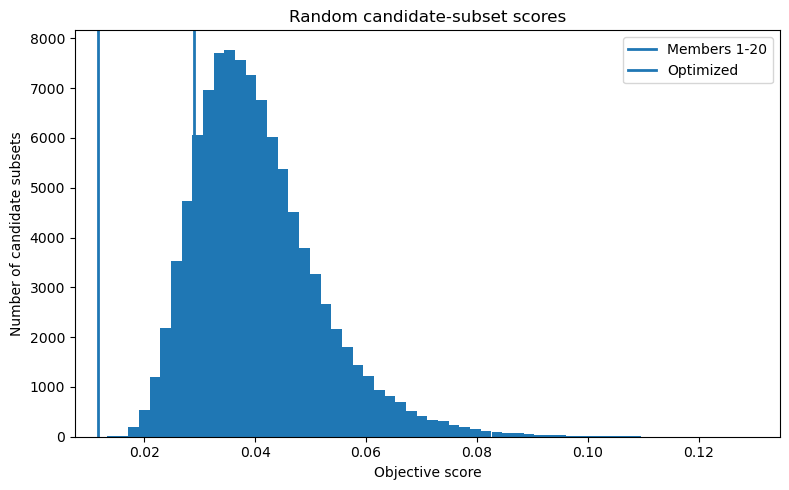

Saved figure: /compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection/2011-12-16-00000/subset_mean_errors_by_feature.png
Saved figure: /compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection/2011-12-16-00000/subset_mean_errors_by_feature.pdf


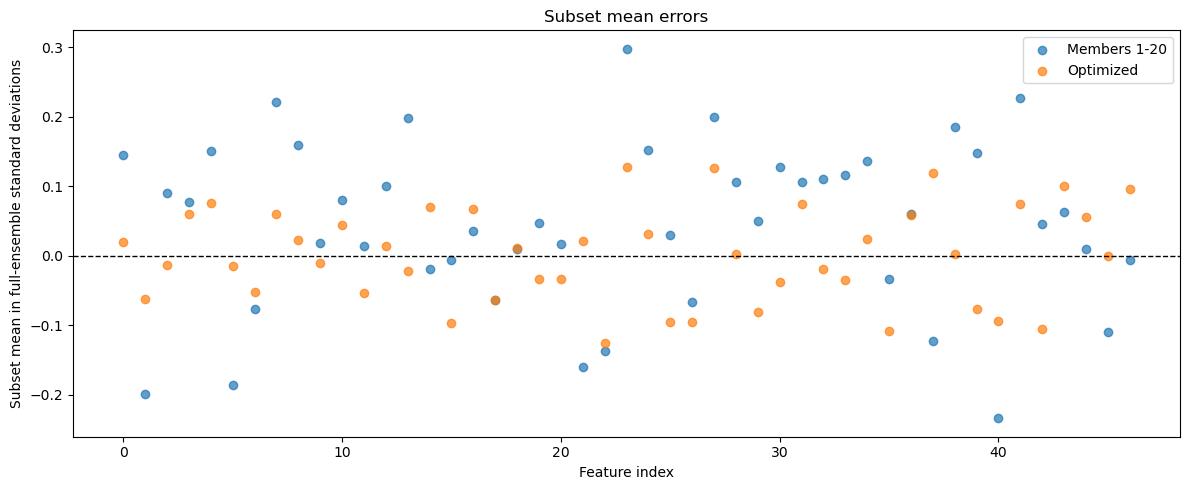

Saved figure: /compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection/2011-12-16-00000/subset_spread_ratio_by_feature.png
Saved figure: /compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection/2011-12-16-00000/subset_spread_ratio_by_feature.pdf


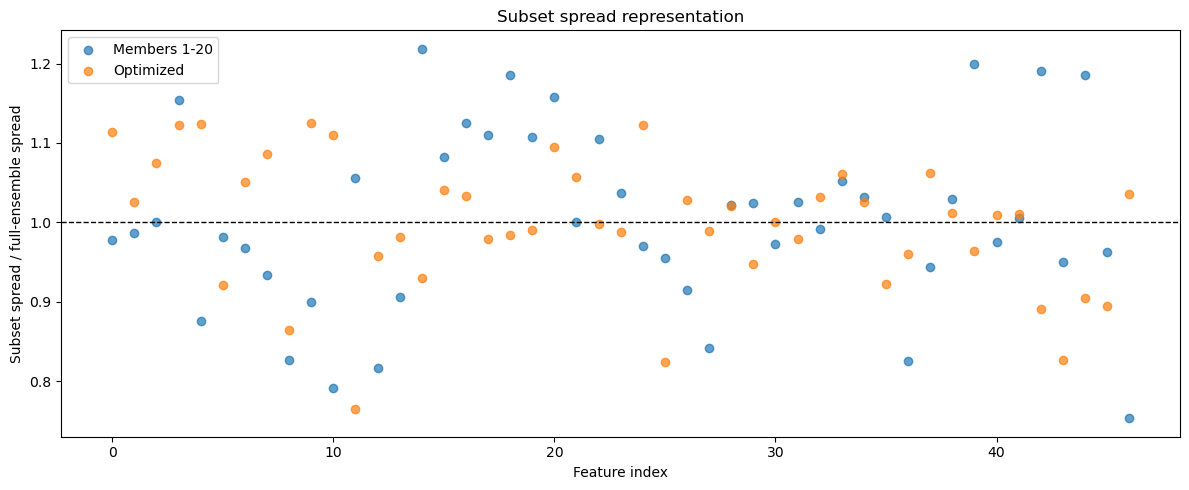

In [17]:
def save_figure(fig, stem):
    png_path = OUTPUT_DIR / f"{stem}.png"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved figure:", png_path)
    print("Saved figure:", pdf_path)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(trial_scores, bins=60)
ax.axvline(first20_score, linewidth=2, label="Members 1-20")
ax.axvline(optimal_score, linewidth=2, label="Optimized")
ax.set_xlabel("Objective score")
ax.set_ylabel("Number of candidate subsets")
ax.set_title("Random candidate-subset scores")
ax.legend()
fig.tight_layout()
save_figure(fig, "random_candidate_subset_scores")
plt.show()

def diagnostics(indices, label):
    X = Z[indices]
    return pd.DataFrame({
        "feature": features_z.columns,
        "feature_index": np.arange(Z.shape[1]),
        "subset_mean": X.mean(axis=0),
        "subset_std": X.std(axis=0, ddof=1),
        "label": label,
    })

diag = pd.concat([
    diagnostics(optimal_indices, "Optimized"),
    diagnostics(first20_indices, "Members 1-20"),
], ignore_index=True)

diag.to_csv(OUTPUT_DIR / "subset_feature_diagnostics.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 5))
for label, group in diag.groupby("label"):
    ax.scatter(group["feature_index"], group["subset_mean"], alpha=0.7, label=label)
ax.axhline(0.0, linestyle="--", color="k", linewidth=1)
ax.set_xlabel("Feature index")
ax.set_ylabel("Subset mean in full-ensemble standard deviations")
ax.set_title("Subset mean errors")
ax.legend()
fig.tight_layout()
save_figure(fig, "subset_mean_errors_by_feature")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for label, group in diag.groupby("label"):
    ax.scatter(group["feature_index"], group["subset_std"], alpha=0.7, label=label)
ax.axhline(1.0, linestyle="--", color="k", linewidth=1)
ax.set_xlabel("Feature index")
ax.set_ylabel("Subset spread / full-ensemble spread")
ax.set_title("Subset spread representation")
ax.legend()
fig.tight_layout()
save_figure(fig, "subset_spread_ratio_by_feature")
plt.show()


## 7. Inspect largest feature mismatches and save results

In [18]:
opt_diag = diagnostics(optimal_indices, "Optimized")
opt_diag["abs_mean_error"] = np.abs(opt_diag["subset_mean"])
opt_diag["abs_spread_error"] = np.abs(opt_diag["subset_std"] - 1.0)
opt_diag["combined_error"] = (
    opt_diag["abs_mean_error"] + opt_diag["abs_spread_error"]
)

display(opt_diag.sort_values("combined_error", ascending=False).head(25))

selection = pd.DataFrame({
    "member": optimal_members,
    "member_label": [f"EN{m:02d}" for m in optimal_members],
})
selection.to_csv(OUTPUT_DIR / "selected_20_members.csv", index=False)
opt_diag.to_csv(OUTPUT_DIR / "optimized_subset_feature_errors.csv", index=False)

metadata = {
    "rest_dir": str(REST_DIR),
    "date_tag": DATE_TAG,
    "n_total": int(len(member_ids)),
    "subset_size": SUBSET_SIZE,
    "n_trials": N_TRIALS,
    "random_seed": RANDOM_SEED,
    "max_sample_points": MAX_SAMPLE_POINTS,
    "min_unique_feature_values": MIN_UNIQUE_FEATURE_VALUES,
    "eam_variables": eam_variables,
    "elm_variables": elm_variables,
    "weights": {
        "mean": WEIGHT_MEAN,
        "std": WEIGHT_STD,
        "covariance": WEIGHT_COV,
    },
    "dask": {
        "enabled": USE_DASK,
        "distributed": USE_DASK_DISTRIBUTED,
        "n_workers": DASK_N_WORKERS,
        "threads_per_worker": DASK_THREADS_PER_WORKER,
        "memory_limit": DASK_MEMORY_LIMIT,
        "feature_task_retries": FEATURE_TASK_RETRIES,
        "random_search_batch_size": RANDOM_SEARCH_BATCH_SIZE,
    },
    "selected_members": optimal_members.tolist(),
    "optimal_score": optimal_parts,
    "members_1_to_20_score": first20_parts,
    "swap_iterations": swap_iterations,
}
with open(OUTPUT_DIR / "selection_metadata.json", "w") as stream:
    json.dump(metadata, stream, indent=2)

print(selection.to_string(index=False))
print("\nSaved to:", OUTPUT_DIR.resolve())


,feature,feature_index,subset_mean,subset_std,label,abs_mean_error,abs_spread_error,combined_error
11,EAM:U:q50,11,-0.053091,0.764592,Optimized,0.053091,0.235408,0.288499
43,ELM:H2OSFC:mean,43,0.101168,0.826277,Optimized,0.101168,0.173723,0.274890
25,EAM:Q:q50,25,-0.094984,0.824167,Optimized,0.094984,0.175833,0.270817
42,ELM:T_SOISNO:q10,42,-0.104858,0.890657,Optimized,0.104858,0.109343,0.214201
4,EAM:T:q50,4,0.075939,1.124196,Optimized,0.075939,0.124196,0.200135
35,ELM:H2OSOI_LIQ:mean,35,-0.108185,0.922685,Optimized,0.108185,0.077315,0.185499
37,ELM:H2OSOI_LIQ:q90,37,0.119935,1.062150,Optimized,0.119935,0.062150,0.182085
3,EAM:T:q25,3,0.059716,1.122209,Optimized,0.059716,0.122209,0.181925
8,EAM:U:std,8,0.022803,0.864104,Optimized,0.022803,0.135896,0.158699
10,EAM:U:q25,10,0.044743,1.109770,Optimized,0.044743,0.109770,0.154513


 member member_label
      1         EN01
      3         EN03
      4         EN04
      7         EN07
      8         EN08
      9         EN09
     10         EN10
     14         EN14
     17         EN17
     18         EN18
     20         EN20
     21         EN21
     25         EN25
     26         EN26
     28         EN28
     31         EN31
     35         EN35
     36         EN36
     37         EN37
     40         EN40

Saved to: /compyfs/www/zhan391/e3sm_dart/ensemble_ic/dart_subset_selection/2011-12-16-00000



## 8. Cross-date validation before launching the campaign

A subset selected only from `2011-12-21` may be unusually representative of that date. Before finalizing it:

1. run the extraction for at least one additional winter date;
2. run it for at least one late-spring date;
3. test the same selected IDs at every date;
4. inspect mean, spread, and covariance errors.

For the strongest common subset, extract the same features at several dates, standardize them separately within each date, concatenate the standardized date-specific features, and repeat the optimization. That produces one subset representing both winter and late spring.
